# 01 - Comprensión de los datos

## Objetivo

Realizar una revisión inicial del dataset de clientes para comprender su estructura, identificar la variable objetivo, reconocer los tipos de variables y detectar posibles problemas de calidad antes de realizar cualquier transformación.

En esta etapa no se modifican los datos originales. Los problemas encontrados se documentan para ser tratados posteriormente durante la limpieza.

## 1. Carga de datos

In [113]:
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path

DATA_PATH = Path("../data/raw/Telco-Customer-Churn.csv")

df = pd.read_csv(DATA_PATH)




## 2. Estructura del dataset

In [114]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [115]:
df.shape

(7043, 21)

In [116]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

## 3. Revisión de tipos de datos

In [117]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Se observa que la columna TotalCharges esta en tipo de dato objet y deberia ser float64, se procede a revisar cuantos valores no pueden ser convertidos a número

In [118]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()

np.int64(11)

Se encontraton 11 valores que no pueden ser convertidos, confirmando que pandas no lo tomo como float64 por estos valores, ahora queda revisar que valores son

In [119]:
df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [120]:
df.loc[
    pd.to_numeric(df["TotalCharges"], errors="coerce").isna(),
    ["tenure", "MonthlyCharges", "TotalCharges"]
]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


TotalCharges está almacenada como object debido a 11 registros con valores en blanco. Los 11 corresponden a clientes con tenure = 0, lo que sugiere clientes nuevos sin cargos totales acumulados. El tratamiento de estos registros se realizarará p en la etapa de limpieza.

Por otro lado, la variable SeniorCitizen, se muestra como int64 y esta puede ser booleana, ya que clasifica entre personas de la tercera edad o no, a continuación se haer revision de que valores tiene esta vairable para revisar que pueder estar afectando esta decision de pandas

In [121]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [122]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

Se procede a identificar cuales columnas pueden ser categoricas y cuales no

In [123]:
categorical_cols = df.select_dtypes(include="str").columns

categorical_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')

Entre las variables, se observa que customerID está almacenada como texto y corresponde a un identificador, mientras que TotalCharges también está almacenada como texto aunque conceptualmente es una variable numérica., mas adelante en la limpieza datos se corregirá esto, esta clasificacion la realiza el dtype y toca observar porque las tomo asi.

A continuacion se procede a revisar que categorias tienen las demas variables

In [124]:
for col in categorical_cols:
    if col not in ['customerID', 'TotalCharges']:
        print(f'{col}: {df[col].unique()}')

gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Contract: <StringArray>
['Month-to-month', 'One year', '

Se muestra que hay las variables categoricas no son solo 'Yes o 'No', existen otras categorias donde se indica si tiene le servicio o no. Tambien se observa que aparece 'Churn' como variable con solo dos categorias, qeu es lo que se busca para poder clasificarcar el modelo. 

## 4. Análisis de la variable objetivo

In [137]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [138]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

La variable objetivo Churn presenta un desbalance moderado, con una mayor proporción de clientes que permanecen en la compañía frente a los que abandonan. Esta distribución deberá considerarse durante el entrenamiento y especialmente durante la evaluación de los modelos.

## 5. Variables numéricas

In [127]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


Aunque TotalCharges se incluyó en la selección, describe() no genera estadísticas numéricas para ella porque Pandas todavía la reconoce como texto.

Como no se han echo modificaciones aun en el dataset, no se muestra los datos de "TotalCharges", debido a que se detecto como texto y no numerica

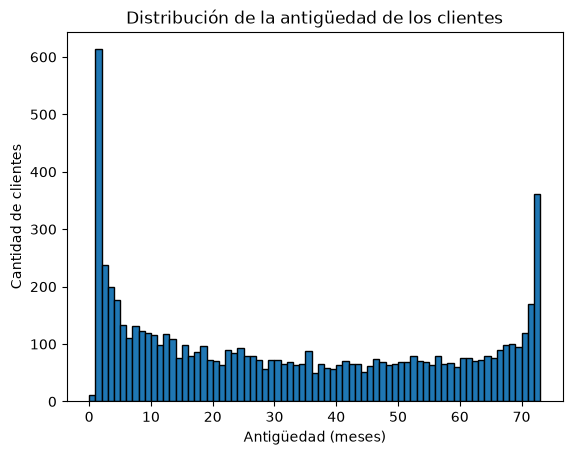

In [128]:
plt.hist(df["tenure"], bins=range(0,74), edgecolor='black')
plt.xlabel("Antigüedad (meses)")
plt.ylabel("Cantidad de clientes")
plt.title("Distribución de la antigüedad de los clientes")
plt.show()

La antigüedad de los clientes presenta una distribución no uniforme, con una elevada concentración de clientes de baja antigüedad y otro incremento entre los clientes de mayor permanencia. Por esta razón, la media por sí sola no representa completamente la distribución.


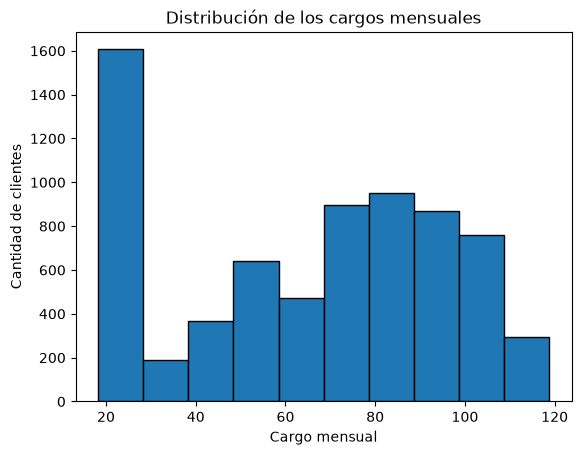

In [129]:
plt.hist(df["MonthlyCharges"], edgecolor='black')
plt.xlabel("Cargo mensual")
plt.ylabel("Cantidad de clientes")
plt.title("Distribución de los cargos mensuales")
plt.show()

La distribución de MonthlyCharges no es uniforme. Se observa una alta concentración de clientes con cargos mensuales bajos, principalmente entre aproximadamente 18 y 30, y otro grupo importante de clientes con cargos entre aproximadamente 70 y 105.

La media del cargo mensual es de 64.76, mientras que la mediana es de 70.35. La concentración de clientes con cargos bajos contribuye a que la media sea inferior a la mediana.

A partir del histograma no se observan valores extremadamente alejados del rango general de los datos. Sin embargo, esta gráfica por sí sola no es suficiente para determinar formalmente la existencia o ausencia de valores atípicos.

La forma de la distribución también plantea la posibilidad de que los cargos mensuales estén relacionados con los servicios contratados por cada cliente, relación que se analizará posteriormente.

## 6. Revisión de duplicados

In [130]:
df.duplicated().sum()

np.int64(0)

In [139]:
df["customerID"].duplicated().sum()

np.int64(0)

In [131]:
df["customerID"].nunique()

7043

No se encontraron registros completamente duplicados y cada customerID identifica de forma única a un cliente, por lo que no se evidencian duplicados a nivel de cliente.

## 7. Valores faltantes y vacíos

In [132]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [133]:
for col in df.select_dtypes(include="str").columns:
    vacios = df[col].str.strip().eq("").sum()
    if vacios > 0:
        print(f"{col}: {vacios}")

TotalCharges: 11


No se encontraron valores nulos reconocidos directamente por Pandas. Sin embargo, al revisar cadenas vacías se identificaron 11 registros en TotalCharges que contienen espacios en blanco. Estos casos corresponden a clientes con tenure = 0, por lo que su tratamiento se realizará posteriormente durante la etapa de limpieza.

## 8. Revisión de variables categóricas

In [134]:
for col in categorical_cols:
    if col not in ["customerID", "TotalCharges", "Churn"]:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False, normalize=True))


--- gender ---
gender
Male      0.504756
Female    0.495244
Name: proportion, dtype: float64

--- Partner ---
Partner
No     0.516967
Yes    0.483033
Name: proportion, dtype: float64

--- Dependents ---
Dependents
No     0.700412
Yes    0.299588
Name: proportion, dtype: float64

--- PhoneService ---
PhoneService
Yes    0.903166
No     0.096834
Name: proportion, dtype: float64

--- MultipleLines ---
MultipleLines
No                  0.481329
Yes                 0.421837
No phone service    0.096834
Name: proportion, dtype: float64

--- InternetService ---
InternetService
Fiber optic    0.439585
DSL            0.343746
No             0.216669
Name: proportion, dtype: float64

--- OnlineSecurity ---
OnlineSecurity
No                     0.496663
Yes                    0.286668
No internet service    0.216669
Name: proportion, dtype: float64

--- OnlineBackup ---
OnlineBackup
No                     0.438450
Yes                    0.344881
No internet service    0.216669
Name: proportion, 

## 9. Hallazgos iniciales

- El dataset contiene **7.043 registros y 21 variables**, donde cada fila representa un cliente.

- La variable objetivo es `Churn`, que indica si un cliente abandonó o no el servicio. Por lo tanto, se trata de un problema de **clasificación binaria**.

- Se identificaron **3 variables numéricas** (`tenure`, `MonthlyCharges` y `TotalCharges`), **16 variables categóricas**, un identificador (`customerID`) y la variable objetivo (`Churn`).

- `customerID` funciona únicamente como identificador de cada cliente y presenta valores únicos para los 7.043 registros. Por esta razón, inicialmente no se considera una variable predictora útil para el modelo.

- `TotalCharges` representa una variable numérica, pero se encuentra almacenada como texto. Se identificaron **11 registros con espacios en blanco** que Pandas no reconoce directamente como valores nulos. Estos registros corresponden a clientes con `tenure = 0`, por lo que su tratamiento se realizará durante la etapa de limpieza.

- No se encontraron **filas completamente duplicadas ni identificadores de clientes repetidos**.

- La variable objetivo `Churn` presenta un **desbalance moderado**, con una mayor proporción de clientes que permanecen en la compañía frente a los que abandonan. Este comportamiento deberá considerarse especialmente durante la evaluación de los modelos.

- `SeniorCitizen` está almacenada como una variable numérica (`0` y `1`), aunque conceptualmente corresponde a una **variable categórica binaria**.

- Las variables categóricas revisadas presentan valores consistentes y no se detectaron inicialmente categorías generadas por diferencias de escritura o formato.

- La distribución de `tenure` muestra una concentración importante de clientes con poca antigüedad y otro grupo de clientes con una permanencia elevada. La distribución no parece normal, por lo que la media por sí sola no describe completamente el comportamiento de esta variable.

- `MonthlyCharges` también presenta una distribución no uniforme, con una concentración importante de clientes con cargos bajos y otro grupo con cargos mensuales considerablemente mayores. Posteriormente se analizará si estas diferencias están relacionadas con los servicios contratados.

### Aspectos que requieren tratamiento posterior

Durante la etapa de limpieza y preparación de los datos se deberá:

1. Convertir `TotalCharges` a un tipo de dato numérico.
2. Definir el tratamiento de los 11 valores vacíos encontrados en `TotalCharges`.
3. Excluir `customerID` de las variables utilizadas para entrenar el modelo.
4. Definir el tratamiento adecuado de las variables categóricas.
5. Considerar el desbalance de `Churn` al seleccionar las métricas de evaluación.